# 基于线性链条件随机场（Linear-Chain CRF）的中文分词教学案例

**课程关联**：对应《自然语言处理导论》第 2 章“词语规范化”与第 6 章统计序列建模思想的实践延伸，也呼应第 1 次课中"机器学习范式"与"规则方法"的对比讨论。

**教学定位**：本 Notebook 不依赖任何现成的 CRF 工具包（如 CRF++、sklearn-crfsuite），而是**从零使用 NumPy 手工实现**线性链 CRF 的核心算法（前向-后向算法、维特比解码、基于梯度的参数估计），目的是让学生透彻理解 CRF 的数学原理，而不仅仅是"调包"。

## 学习目标

1. 理解中文分词任务如何转化为**字符级序列标注问题**（BMES 标注体系）。
2. 理解线性链 CRF 的条件概率定义、特征函数设计与全局归一化（配分函数）的含义。
3. 掌握前向-后向算法计算配分函数与边缘概率、维特比算法求解最优标签序列的流程。
4. 能够动手训练一个小型 CRF 分词模型，并用标准指标（准确率/召回率/F1）评估效果。
5. 通过与"正向最大匹配"规则方法对比，直观理解统计方法相对词典方法的泛化优势。

> **说明**：为便于教学演示与课堂运行速度，本案例使用手工构造的小型语料库（约 30 个句子），模型规模也做了精简。该设置足以说明 CRF 的完整原理与训练流程，但**不代表工业级分词器的规模与效果**；如需生产级效果，应使用大规模标注语料（如 PKU/MSR/CTB 分词语料）及更丰富的特征模板。


## 一、任务定义：中文分词 = 字符级序列标注

中文文本词与词之间没有自然分隔符（不像英文有空格），因此分词的第一步是判断"字与字之间是否存在词语边界"。一种经典且效果良好的建模思路是把分词转化为**字符级序列标注问题**：为句子中的每一个字符打上一个标签，标签描述该字符在其所属词语中的位置。

最常用的标注体系是 **BMES**：

| 标签 | 含义 | 示例（词语"自然语言"） |
| --- | --- | --- |
| B (Begin) | 词语的第一个字 | 自 |
| M (Middle) | 词语的中间字 | 然、语 |
| E (End) | 词语的最后一个字 | 言 |
| S (Single) | 单字成词 | 是 |

例如句子"自然语言处理是重要方向"分词为 `自然/语言/处理/是/重要/方向`，对应的字符-标签序列为：

```
自 然 语 言 处 理 是 重 要 方 向
B  E  B  E  B  E  S  B  E  B  E
```

只要能正确预测出每个字的 BMES 标签，就能唯一地还原出分词结果。这样，中文分词就转化为了一个经典的**序列标注任务**，可以用 HMM、CRF、BiLSTM-CRF 等序列模型求解。本案例聚焦其中最经典、可解释性最强的**线性链条件随机场（Linear-Chain CRF）**。


## 二、线性链条件随机场原理回顾

### 1. 条件概率定义

给定输入字符序列 $x = (x_1, \dots, x_n)$，线性链 CRF 对标签序列 $y=(y_1,\dots,y_n)$ 定义如下条件概率：

$$
P(y \mid x) = \frac{1}{Z(x)} \exp\left( \sum_{i=1}^{n} \sum_k w_k f_k(y_{i-1}, y_i, x, i) \right)
$$

其中：
- $f_k(\cdot)$ 是**特征函数**，可以依赖于当前位置的观测 $x$、当前标签 $y_i$ 以及前一个标签 $y_{i-1}$；
- $w_k$ 是特征函数对应的可学习权重；
- $Z(x) = \sum_{y'} \exp\left(\sum_i \sum_k w_k f_k(y'_{i-1}, y'_i, x, i)\right)$ 是**配分函数（归一化常数）**，对所有可能的标签序列求和。

本案例采用工业界最常见的特征分解方式，将特征函数拆分为两类：

- **状态特征（State Feature）**：只依赖于观测 $x$、位置 $i$ 和当前标签 $y_i$（例如"当前字是'处'且标签为 B"），对应本案例中的 `U00`~`U04` 特征模板；
- **转移特征（Transition Feature）**：只依赖于相邻两个标签 $(y_{i-1}, y_i)$（例如"前一个标签是 B，当前标签是 M"），刻画标签之间的合法转移模式（如 B 后面通常接 M 或 E，不会紧跟 B）。

这种分解方式既降低了参数规模，又保留了 CRF **全局归一化**（相对于 MEMM 逐位置局部归一化）的核心优势，能够避免标注偏置问题（Label Bias Problem）。

### 2. 训练：最大化对数似然

给定标注语料 $\{(x^{(j)}, y^{(j)})\}$，CRF 通过最大化对数似然（等价于最小化负对数似然）来估计参数：

$$
\mathcal{L}(w) = \sum_j \left[ \sum_i \sum_k w_k f_k(y^{(j)}_{i-1}, y^{(j)}_i, x^{(j)}, i) - \log Z(x^{(j)}) \right]
$$

其梯度具有非常直观的形式——**"经验特征期望"减去"模型预测下的特征期望"**：

$$
\frac{\partial \mathcal{L}}{\partial w_k} = \sum_j \left[ \sum_i f_k(y^{(j)}_{i-1}, y^{(j)}_i, x^{(j)}, i) - \mathbb{E}_{P(y\mid x^{(j)})}\left[\sum_i f_k(y_{i-1}, y_i, x^{(j)}, i)\right] \right]
$$

其中期望项需要用**前向-后向算法**在对数空间高效计算（避免枚举指数级的标签序列组合）：

- 前向变量：$\alpha_i(y) = \text{score}(y \text{ 到位置 } i \text{ 为止的所有路径})$
- 后向变量：$\beta_i(y) = \text{score}(\text{从位置 } i \text{ 到末尾，标签为 } y \text{ 的所有路径})$
- 边缘概率：$P(y_i = y \mid x) = \dfrac{\exp(\alpha_i(y) + \beta_i(y))}{Z(x)}$

### 3. 解码：维特比算法

训练完成后，对新句子求最优标签序列使用**维特比算法**（动态规划），求解：

$$
\hat{y} = \arg\max_y P(y \mid x) = \arg\max_y \sum_i \sum_k w_k f_k(y_{i-1}, y_i, x, i)
$$

下面我们将这三部分（前向-后向、梯度、维特比）逐一用 NumPy 实现。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)
%matplotlib inline


## 三、构造教学用小型分词语料库

为了让课堂能在几分钟内完成"训练+评估+预测"全流程，这里手工构造了 30 个已正确分词的中文句子（词表围绕"自然语言处理"课程主题设计，方便与前面课程内容呼应）。真实项目中应使用 PKU、MSR、CTB 等大规模标注语料库。

每个句子已经以"词语列表"的形式给出（即分词的**标准答案/Ground Truth**），我们编写函数将其自动转换为字符级 BMES 标签序列。


In [2]:
sentences_words = [
    ["自然", "语言", "处理", "是", "人工智能", "的", "一个", "重要", "方向"],
    ["我们", "正在", "学习", "中文", "分词", "方法"],
    ["条件", "随机场", "可以", "用于", "序列", "标注", "任务"],
    ["每个", "句子", "中", "的", "每个", "字", "都", "被", "标记", "为", "一个", "标签"],
    ["词语", "的", "边界", "需要", "由", "模型", "自动", "识别"],
    ["模型", "的", "训练", "需要", "大量", "标注", "数据"],
    ["测试", "集合", "用于", "评估", "模型", "的", "性能"],
    ["这个", "任务", "非常", "有趣", "也", "很", "有", "挑战"],
    ["计算机", "需要", "把", "文本", "转换", "成", "可以", "处理", "的", "形式"],
    ["深度", "学习", "算法", "近年来", "发展", "迅速"],
    ["自然", "语言", "处理", "包括", "分词", "句法", "分析", "和", "语义", "分析"],
    ["中文", "分词", "是", "自然", "语言", "处理", "的", "基础", "任务"],
    ["条件", "随机场", "是", "一种", "判别", "式", "概率", "模型"],
    ["我们", "使用", "标注", "数据", "训练", "条件", "随机场", "模型"],
    ["句子", "中", "每个", "字", "的", "标签", "由", "上下文", "特征", "决定"],
    ["特征", "模板", "决定", "了", "模型", "能够", "学到", "什么", "信息"],
    ["维特比", "算法", "用于", "寻找", "最", "优", "标签", "序列"],
    ["前向", "后向", "算法", "用于", "计算", "配", "分", "函数"],
    ["模型", "训练", "完成", "后", "可以", "用来", "预测", "新", "句子"],
    ["我们", "还", "会", "评估", "分词", "的", "精确率", "和", "召回率"],
    ["自然", "语言", "处理", "近年来", "发展", "非常", "迅速"],
    ["人工智能", "的", "研究", "方向", "包括", "机器", "学习", "和", "深度", "学习"],
    ["这个", "模型", "在", "测试", "集合", "上", "的", "表现", "不错"],
    ["我们", "希望", "模型", "能够", "正确", "识别", "词语", "的", "边界"],
    ["训练", "数据", "的", "质量", "会", "影响", "模型", "的", "性能"],
    ["分词", "任务", "的", "评估", "指标", "包括", "精确率", "召回率", "和", "F1", "值"],
    ["计算机", "能够", "理解", "文本", "的", "前提", "是", "正确", "的", "分词"],
    ["我们", "在", "课堂", "上", "学习", "了", "条件", "随机场", "的", "原理"],
    ["这个", "语料", "库", "虽然", "很", "小", "但", "足够", "用于", "教学"],
    ["模型", "的", "参数", "通过", "梯度", "上升", "算法", "进行", "更新"],
]

print(f"语料库共 {len(sentences_words)} 个句子")


语料库共 30 个句子


In [3]:
def word_to_bmes(word):
    """将一个词语转换为对应长度的 BMES 标签序列"""
    n = len(word)
    if n == 1:
        return ["S"]
    return ["B"] + ["M"] * (n - 2) + ["E"]

def sentence_to_chars_tags(words):
    """将词语列表展开为 (字符列表, 标签列表)"""
    chars, tags = [], []
    for w in words:
        chars.extend(list(w))
        tags.extend(word_to_bmes(w))
    return chars, tags

dataset = [sentence_to_chars_tags(ws) for ws in sentences_words]

# 展示第一个样本，直观感受"字-标签"对齐关系
chars0, tags0 = dataset[0]
display(pd.DataFrame([chars0, tags0], index=["字符", "BMES标签"]))


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
字符,自,然,语,言,处,理,是,人,工,智,能,的,一,个,重,要,方,向
BMES标签,B,E,B,E,B,E,S,B,M,M,E,S,B,E,B,E,B,E


In [4]:
# 划分训练集 / 测试集（8:2）
rng = np.random.RandomState(42)
idx = list(range(len(dataset)))
rng.shuffle(idx)
n_test = max(3, int(len(dataset) * 0.2))
test_idx = set(idx[:n_test])

train_data = [dataset[i] for i in range(len(dataset)) if i not in test_idx]
test_data = [dataset[i] for i in range(len(dataset)) if i in test_idx]

print(f"训练集句子数：{len(train_data)}")
print(f"测试集句子数：{len(test_data)}")


训练集句子数：24
测试集句子数：6


## 四、特征模板设计

特征模板（Feature Template）决定了模型"能看到什么信息"，是 CRF 效果的关键。本案例采用中文分词任务中最常用、也是 CRF++ 官方分词示例中使用的经典模板组合：

| 模板编号 | 定义 | 含义 |
| --- | --- | --- |
| U00 | $c_{-1}$ | 前一个字 |
| U01 | $c_{0}$ | 当前字 |
| U02 | $c_{1}$ | 后一个字 |
| U03 | $c_{-1}c_{0}$ | 前一个字+当前字（二元组合） |
| U04 | $c_{0}c_{1}$ | 当前字+后一个字（二元组合） |

例如对句子"处理"中的"理"字（位置 $i=5$，句子为"自然语言处理"），特征为：
`U00:处`、`U01:理`、`U02:<PAD>`（句尾用占位符）、`U03:处理`、`U04:理<PAD>`。也就是说给定一个位置$i$得到了5个特征 。

每条模板字符串在与具体标签 $y_i$ 组合后，就构成了状态特征函数 $f_k(y_i, x, i) = \mathbb{1}[\text{模板} t \text{ 在位置 } i \text{ 触发} \wedge y_i = a]$。加上标签二元转移特征，即构成完整的 CRF 特征集合。

> 教学提示：模板越丰富（如加入 $c_{-2}, c_{2}$、三元组合等），模型表达能力越强，但也需要更多训练数据支撑，否则容易过拟合——这正是特征工程时代 NLP 的核心权衡。


In [5]:
LABELS = ["B", "M", "E", "S"]
L2I = {l: i for i, l in enumerate(LABELS)}
NUM_LABELS = len(LABELS)

def char_at(chars, i):
    """越界返回占位符 <PAD>，用于表示句首/句尾"""
    if i < 0 or i >= len(chars):
        return "<PAD>"
    return chars[i]

def extract_templates(chars, i):
    """对句子 chars 的第 i 个位置，抽取 U00~U04 五个特征模板字符串"""
    c_1, c0, c1 = char_at(chars, i - 1), char_at(chars, i), char_at(chars, i + 1)
    return [
        f"U00:{c_1}",
        f"U01:{c0}",
        f"U02:{c1}",
        f"U03:{c_1}{c0}",
        f"U04:{c0}{c1}",
    ]

# 演示：查看"自然语言处理"中"理"字（下标5）的特征
demo_chars = list("自然语言处理")
print(extract_templates(demo_chars, 5))


['U00:处', 'U01:理', 'U02:<PAD>', 'U03:处理', 'U04:理<PAD>']


In [6]:
# 构建特征词表：训练阶段遇到新特征就登记新 id；测试/预测阶段只使用已登记特征（未登记的特征直接忽略，权重视为0）
feat2id = {}

def get_feat_id(f, allow_new):
    if f in feat2id:
        return feat2id[f]
    if allow_new:
        fid = len(feat2id)
        feat2id[f] = fid
        return fid
    return -1  # 未登录特征，权重视为0（体现了小语料模型对未见特征无能为力的局限）

def sentence_feature_ids(chars, allow_new):
    """把一个句子转换为 [[位置0的特征id列表], [位置1的特征id列表], ...]"""
    return [[get_feat_id(f, allow_new) for f in extract_templates(chars, i)]
            for i in range(len(chars))]

for chars, _ in train_data:
    print(chars)
    for i in range(len(chars)):
        for f in extract_templates(chars, i):
            print(f)
            print(i)
            print(get_feat_id(f, allow_new=True))
    break
            
train_feat_ids = [sentence_feature_ids(chars, allow_new=True) for chars, _ in train_data]
# print(len(train_feat_ids))
# print(len(train_feat_ids[1]))
# print(train_feat_ids[1])
test_feat_ids = [sentence_feature_ids(chars, allow_new=False) for chars, _ in test_data]
# print(test_feat_ids)
NUM_FEATS = len(feat2id)
print(f"从训练语料中共登记 {NUM_FEATS} 个不同的特征模板实例")
print(feat2id)


['自', '然', '语', '言', '处', '理', '是', '人', '工', '智', '能', '的', '一', '个', '重', '要', '方', '向']
U00:<PAD>
0
0
U01:自
0
1
U02:然
0
2
U03:<PAD>自
0
3
U04:自然
0
4
U00:自
1
5
U01:然
1
6
U02:语
1
7
U03:自然
1
8
U04:然语
1
9
U00:然
2
10
U01:语
2
11
U02:言
2
12
U03:然语
2
13
U04:语言
2
14
U00:语
3
15
U01:言
3
16
U02:处
3
17
U03:语言
3
18
U04:言处
3
19
U00:言
4
20
U01:处
4
21
U02:理
4
22
U03:言处
4
23
U04:处理
4
24
U00:处
5
25
U01:理
5
26
U02:是
5
27
U03:处理
5
28
U04:理是
5
29
U00:理
6
30
U01:是
6
31
U02:人
6
32
U03:理是
6
33
U04:是人
6
34
U00:是
7
35
U01:人
7
36
U02:工
7
37
U03:是人
7
38
U04:人工
7
39
U00:人
8
40
U01:工
8
41
U02:智
8
42
U03:人工
8
43
U04:工智
8
44
U00:工
9
45
U01:智
9
46
U02:能
9
47
U03:工智
9
48
U04:智能
9
49
U00:智
10
50
U01:能
10
51
U02:的
10
52
U03:智能
10
53
U04:能的
10
54
U00:能
11
55
U01:的
11
56
U02:一
11
57
U03:能的
11
58
U04:的一
11
59
U00:的
12
60
U01:一
12
61
U02:个
12
62
U03:的一
12
63
U04:一个
12
64
U00:一
13
65
U01:个
13
66
U02:重
13
67
U03:一个
13
68
U04:个重
13
69
U00:个
14
70
U01:重
14
71
U02:要
14
72
U03:个重
14
73
U04:重要
14
74
U00:重
15
75
U01:要
15
76
U02:方
1

## 五、从零实现线性链 CRF

下面用一个 `LinearChainCRF` 类完整实现：

1. `node_scores`：根据状态特征权重 `W`，计算每个位置对每个标签的"局部得分"（对应 $\sum_k w_k f_k(y_i,x,i)$）；
2. `forward_backward`：对数空间的前向-后向算法，计算配分函数 $Z(x)$ 与边缘概率；
3. `viterbi`：动态规划求解最优标签序列；
4. `neg_log_likelihood_and_grad`：计算单个句子的负对数似然及梯度（含 L2 正则）；
5. `fit`：使用 Adam 优化器对全体训练句子做批量梯度上升训练。

代码中 `self.W` 对应状态特征权重矩阵（形状为 `[特征数, 标签数]`），`self.T` 对应标签转移权重矩阵（形状为 `[标签数, 标签数]`，`T[a,b]` 表示标签 a 转移到标签 b 的得分）。


In [7]:
class LinearChainCRF:
    def __init__(self, num_feats, num_labels):
        self.num_feats = num_feats
        self.num_labels = num_labels
        self.W = np.zeros((num_feats, num_labels))   # 状态特征权重
        self.T = np.zeros((num_labels, num_labels))  # 标签转移权重 T[y_prev, y_cur]

    def node_scores(self, feat_ids):
        """计算每个位置、每个标签的状态得分矩阵，形状 [n, num_labels]"""
        n = len(feat_ids)
        scores = np.zeros((n, self.num_labels))
        for i in range(n):
            ids = [f for f in feat_ids[i] if f >= 0]
            if ids:
                scores[i] = self.W[ids].sum(axis=0)
        return scores

    @staticmethod
    def logsumexp(a, axis=None):
        amax = np.max(a, axis=axis, keepdims=True)
        out = amax + np.log(np.sum(np.exp(a - amax), axis=axis, keepdims=True))
        return np.squeeze(out, axis=axis) if axis is not None else out

    def forward_backward(self, node_sc):
        """对数空间前向-后向算法，返回 alpha, beta, 配分函数对数 Z"""
        n = node_sc.shape[0]
        L = self.num_labels
        alpha = np.zeros((n, L))
        alpha[0] = node_sc[0]
        for i in range(1, n):
            alpha[i] = node_sc[i] + self.logsumexp(alpha[i - 1][:, None] + self.T, axis=0)

        beta = np.zeros((n, L))
        beta[-1] = 0.0
        for i in range(n - 2, -1, -1):
            beta[i] = self.logsumexp(self.T + node_sc[i + 1][None, :] + beta[i + 1][None, :], axis=1)

        Z = self.logsumexp(alpha[-1], axis=0)
        return alpha, beta, Z

    def viterbi(self, feat_ids):
        """维特比算法求解最优标签序列"""
        node_sc = self.node_scores(feat_ids)
        n = node_sc.shape[0]
        L = self.num_labels
        dp = np.zeros((n, L))
        bp = np.zeros((n, L), dtype=int)
        dp[0] = node_sc[0]
        for i in range(1, n):
            scores = dp[i - 1][:, None] + self.T
            bp[i] = np.argmax(scores, axis=0)
            dp[i] = node_sc[i] + np.max(scores, axis=0)
        y = [int(np.argmax(dp[-1]))]
        for i in range(n - 1, 0, -1):
            y.append(int(bp[i][y[-1]]))
        y.reverse()
        return [LABELS[k] for k in y]

    def neg_log_likelihood_and_grad(self, feat_ids, tag_ids, l2=0.01):
        """计算单句负对数似然及关于 W, T 的梯度（经验特征计数 - 期望特征计数）"""
        node_sc = self.node_scores(feat_ids)
        alpha, beta, Z = self.forward_backward(node_sc)
        n = node_sc.shape[0]

        gold_score = node_sc[np.arange(n), tag_ids].sum() + sum(
            self.T[tag_ids[i], tag_ids[i + 1]] for i in range(n - 1)
        )
        nll = Z - gold_score  # 负对数似然 = logZ - 标准答案路径得分

        gradW = np.zeros_like(self.W)
        gradT = np.zeros_like(self.T)

        # 单点边缘概率 P(y_i = y | x)
        marg = np.exp(alpha + beta - Z)
        for i in range(n):
            marg_i = marg[i].copy()
            marg_i[tag_ids[i]] -= 1.0  # 经验计数(=1) - 期望计数
            for f in feat_ids[i]:
                if f >= 0:
                    gradW[f] += marg_i

        # 相邻两点联合边缘概率 P(y_{i-1}=a, y_i=b | x)，用于转移特征梯度
        for i in range(n - 1):
            pair = np.exp(alpha[i][:, None] + self.T + node_sc[i + 1][None, :] + beta[i + 1][None, :] - Z)
            pair[tag_ids[i], tag_ids[i + 1]] -= 1.0
            gradT += pair

        # L2 正则
        nll += l2 * (np.sum(self.W ** 2) + np.sum(self.T ** 2))
        gradW += 2 * l2 * self.W
        gradT += 2 * l2 * self.T
        return nll, gradW, gradT

    def fit(self, feat_ids_list, tags_list, epochs=60, lr=0.5, l2=0.01, verbose=True):
        """使用 Adam 优化器做批量梯度上升（最小化负对数似然）"""
        mW, vW = np.zeros_like(self.W), np.zeros_like(self.W)
        mT, vT = np.zeros_like(self.T), np.zeros_like(self.T)
        beta1, beta2, eps = 0.9, 0.999, 1e-8
        t = 0
        losses = []
        for epoch in range(epochs):
            total_loss = 0.0
            gW_acc = np.zeros_like(self.W)
            gT_acc = np.zeros_like(self.T)
            for feat_ids, tags in zip(feat_ids_list, tags_list):
                tag_ids = [L2I[tg] for tg in tags]
                nll, gW, gT = self.neg_log_likelihood_and_grad(feat_ids, tag_ids, l2=l2)
                total_loss += nll
                gW_acc += gW
                gT_acc += gT
            t += 1
            for (param, grad, m, v) in [(self.W, gW_acc, mW, vW), (self.T, gT_acc, mT, vT)]:
                m[:] = beta1 * m + (1 - beta1) * grad
                v[:] = beta2 * v + (1 - beta2) * (grad ** 2)
                mhat = m / (1 - beta1 ** t)
                vhat = v / (1 - beta2 ** t)
                param -= lr * mhat / (np.sqrt(vhat) + eps)
            losses.append(total_loss / len(feat_ids_list))
            if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
                print(f"epoch {epoch:3d}  平均负对数似然 = {losses[-1]:.4f}")
        return losses


## 六、模型训练

实例化模型并训练。训练目标是最小化平均负对数似然（等价于最大化训练语料的条件概率）。可以观察损失曲线随迭代次数下降，理解梯度上升的收敛过程。


epoch   0  平均负对数似然 = 22.1807
epoch  10  平均负对数似然 = 4.8122
epoch  20  平均负对数似然 = 3.3652
epoch  30  平均负对数似然 = 1.9627
epoch  40  平均负对数似然 = 1.6052
epoch  50  平均负对数似然 = 1.4983
epoch  59  平均负对数似然 = 1.4445


D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-pack

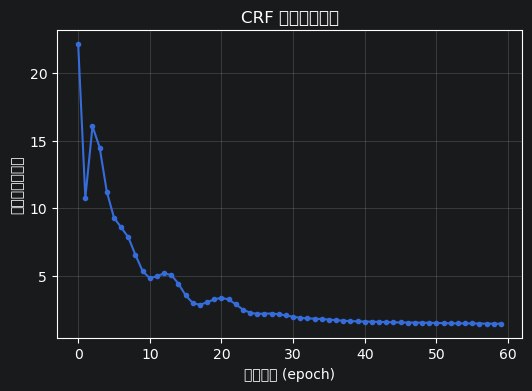

In [8]:
crf = LinearChainCRF(NUM_FEATS, NUM_LABELS)
train_tags = [tags for _, tags in train_data]

losses = crf.fit(train_feat_ids, train_tags, epochs=60, lr=0.5, l2=0.01)

plt.figure(figsize=(6, 4))
plt.plot(losses, marker="o", markersize=3)
plt.xlabel("训练轮次 (epoch)")
plt.ylabel("平均负对数似然")
plt.title("CRF 训练损失曲线")
plt.grid(alpha=0.3)
plt.show()


## 七、模型评估：分词 P / R / F1

分词效果的标准评价方式并非逐字符标签准确率，而是**逐"词语片段"（span）比较**：将预测的 BMES 序列还原为若干 `(起始位置, 结束位置)` 词语区间，与标准答案的词语区间取交集计算：

$$
P = \frac{\text{预测正确的词语数}}{\text{预测的词语总数}}, \quad
R = \frac{\text{预测正确的词语数}}{\text{标准答案的词语总数}}, \quad
F1 = \frac{2PR}{P+R}
$$

这与教材第 3 章介绍的成分句法分析 PARSEVAL 评价思想（LP/LR）是一致的——都是对"预测片段集合"与"标准片段集合"做匹配统计。


In [9]:
def bmes_to_spans(tags):
    """将 BMES 标签序列还原为词语的 (起始, 结束) 闭区间集合"""
    spans = []
    start = None
    for i, tg in enumerate(tags):
        if tg in ("B", "S"):
            start = i
        if tg in ("E", "S"):
            spans.append((start, i))
    return spans

def bmes_to_words(chars, tags):
    """将 BMES 标签序列还原为分词结果（词语字符串列表）"""
    words, cur = [], ""
    for ch, tg in zip(chars, tags):
        if tg == "S":
            if cur:
                words.append(cur); cur = ""
            words.append(ch)
        elif tg == "B":
            if cur:
                words.append(cur)
            cur = ch
        elif tg == "M":
            cur += ch
        elif tg == "E":
            cur += ch
            words.append(cur); cur = ""
    if cur:
        words.append(cur)
    return words

correct = pred_total = gold_total = 0
rows = []
for (chars, gold_tags), feat_ids in zip(test_data, test_feat_ids):
    pred_tags = crf.viterbi(feat_ids)
    gold_spans = set(bmes_to_spans(gold_tags))
    pred_spans = set(bmes_to_spans(pred_tags))
    correct += len(gold_spans & pred_spans)
    pred_total += len(pred_spans)
    gold_total += len(gold_spans)
    rows.append({
        "标准分词": "/".join(bmes_to_words(chars, gold_tags)),
        "模型分词": "/".join(bmes_to_words(chars, pred_tags)),
    })

P = correct / pred_total if pred_total else 0.0
R = correct / gold_total if gold_total else 0.0
F1 = 2 * P * R / (P + R) if (P + R) else 0.0

display(pd.DataFrame(rows))
print(f"\n测试集分词效果  precision={P:.3f}  recall={R:.3f}  F1={F1:.3f}")


,标准分词,模型分词
0,计算机/需要/把/文本/转换/成/可以/处理/的/形式,计算机/需要/把文/本转/换成/可以/处理/的/形式
1,深度/学习/算法/近年来/发展/迅速,深度/学习/算法/近年来/发展/迅速
2,特征/模板/决定/了/模型/能够/学到/什么/信息,特征/模板/决定/了/模型/能够/学到/什么/信息
3,前向/后向/算法/用于/计算/配/分/函数,前向/后向/算法/用于/计算/配分/函数
4,我们/希望/模型/能够/正确/识别/词语/的/边界,我们/希望/模型/能够/正确/识别/词语/的/边界
5,我们/在/课堂/上/学习/了/条件/随机场/的/原理,我们/在/课堂/上学/习了/条件/随机场/的/原理



测试集分词效果  precision=0.878  recall=0.827  F1=0.851


## 八、在新句子上测试

下面用几个**未出现在训练语料中的新句子**测试模型的泛化能力，直观感受 CRF 模型学到了哪些规律（例如常见二字词的组合模式、"近年来"这类三字词的 BME 模式等）。


In [10]:
def segment(sentence, model):
    chars = list(sentence)
    feat_ids = sentence_feature_ids(chars, allow_new=False)
    tags = model.viterbi(feat_ids)
    return bmes_to_words(chars, tags)

demo_sentences = [
    "自然语言处理需要用到条件随机场模型",
    "这个语料库虽然很小但足够用于教学任务",
    "深度学习算法近年来发展非常迅速",
    "我们希望通过这次课堂练习理解序列标注的基本原理",
]

for s in demo_sentences:
    print(s)
    print("  → " + "/".join(segment(s, crf)))
    print()


自然语言处理需要用到条件随机场模型
  → 自然/语言/处理/需要/用到/条件/随机场/模型

这个语料库虽然很小但足够用于教学任务
  → 这个/语料/库/虽然/很/小/但/足够/用于/教学/任务

深度学习算法近年来发展非常迅速
  → 深度/学习/算法/近年来/发展/非常/迅速

我们希望通过这次课堂练习理解序列标注的基本原理
  → 我们/希望/通过/这次/课堂/练习/理解/序列/标注/的/基本/原理



## 九、拓展对比：与"正向最大匹配"规则方法对比

呼应第 1 次课"规则方法 vs 统计方法"的对比讨论：这里实现一个经典的**正向最大匹配（Forward Maximum Matching, FMM）**分词器作为规则方法基线——它依赖一个固定词典，从左到右每次尽量匹配词典中最长的词。

对比二者在同一批新句子上的表现，可以直观看到：
- 当句子完全由词典中的词组成时，两种方法效果相近；
- 当出现词典中**没有的词语组合**（如"用到"没有作为一个整词出现在训练语料中）时，规则方法只能按字拆分，而统计模型可能凭借学到的字符级模式给出更合理的切分——这正是统计方法相对词典方法的**泛化能力优势**，也是历史上分词技术从规则方法走向统计方法的核心动因。


In [11]:
# 用训练语料中出现过的所有词语构造词典
vocab = set()
for ws in sentences_words:
    vocab.update(ws)
max_word_len = max(len(w) for w in vocab)

def forward_maximum_matching(text, vocab, max_len):
    words = []
    i, n = 0, len(text)
    while i < n:
        matched = False
        for l in range(min(max_len, n - i), 0, -1):
            piece = text[i:i + l]
            if piece in vocab:
                words.append(piece)
                i += l
                matched = True
                break
        if not matched:  # 单字未登录，只能按单字切分
            words.append(text[i])
            i += 1
    return words

rows = []
for s in demo_sentences:
    rows.append({
        "原句": s,
        "CRF 分词": "/".join(segment(s, crf)),
        "最大匹配分词": "/".join(forward_maximum_matching(s, vocab, max_word_len)),
    })
display(pd.DataFrame(rows))


,原句,CRF 分词,最大匹配分词
0,自然语言处理需要用到条件随机场模型,自然/语言/处理/需要/用到/条件/随机场/模型,自然/语言/处理/需要/用/到/条件/随机场/模型
1,这个语料库虽然很小但足够用于教学任务,这个/语料/库/虽然/很/小/但/足够/用于/教学/任务,这个/语料/库/虽然/很/小/但/足够/用于/教学/任务
2,深度学习算法近年来发展非常迅速,深度/学习/算法/近年来/发展/非常/迅速,深度/学习/算法/近年来/发展/非常/迅速
3,我们希望通过这次课堂练习理解序列标注的基本原理,我们/希望/通过/这次/课堂/练习/理解/序列/标注/的/基本/原理,我们/希望/通过/这/次/课堂/练/习/理解/序列/标注/的/基/本/原理


## 十、（选修）模型可解释性：查看学到的高权重特征

CRF 相比神经网络的一大优势是**可解释性强**——每个特征的权重都对应明确的语言学含义。下面查看"标签为 B（词首）"权重最高的若干状态特征，可以观察模型学到了哪些字符倾向于出现在词首。


In [12]:
id2feat = {v: k for k, v in feat2id.items()}
label = "B"
li = L2I[label]
top_k = 15
weights_for_label = crf.W[:, li]
top_idx = np.argsort(-weights_for_label)[:top_k]

df = pd.DataFrame({
    "特征模板": [id2feat[i] for i in top_idx],
    f"权重(标签={label})": [weights_for_label[i] for i in top_idx],
})
display(df)

print("\n标签转移权重矩阵 T[y_prev, y_cur]（行=前一个标签，列=当前标签）：")
display(pd.DataFrame(crf.T, index=LABELS, columns=LABELS).round(2))


,特征模板,权重(标签=B)
0,U00:<PAD>,1.297034
1,U00:的,0.919828
2,U00:和,0.508262
3,U00:是,0.472440
4,U02:个,0.395511
5,U02:确,0.356590
6,U01:标,0.328793
7,U04:召回,0.325522
8,U02:回,0.325522
9,U01:召,0.325522



标签转移权重矩阵 T[y_prev, y_cur]（行=前一个标签，列=当前标签）：


,B,M,E,S
B,-1.72,1.09,3.07,-1.28
M,-1.21,-0.04,1.08,-0.81
E,1.71,-1.23,-1.75,1.41
S,1.27,-0.87,-1.33,0.85


可以观察到转移权重矩阵中，`B→M`、`B→E`、`M→M`、`M→E`、`E→B`、`E→S`、`S→B`、`S→S` 等符合 BMES 语法约束的转移通常权重较高，而 `B→B`、`B→S`、`E→M`、`E→E` 等不合语法的转移权重通常很低甚至为负——这说明模型即使没有被显式告知"标签转移规则"，也能**从数据中自动学到**这些结构约束，这正是 CRF 相比逐字符独立分类模型（如朴素的 Softmax 分类器）的核心优势：它对整条标签序列做全局建模，而不是逐点独立决策。


## 十一、总结与思考题

### 本课小结

1. 中文分词可转化为字符级 BMES 序列标注问题；
2. 线性链 CRF 通过状态特征+转移特征对整条标签序列做**全局归一化**建模，训练目标是最大化条件对数似然，梯度 = 经验特征期望 − 模型预测特征期望；
3. 前向-后向算法用于高效计算配分函数与边缘概率（训练），维特比算法用于求解最优路径（预测）；
4. 与规则方法（最大匹配）相比，统计方法具有更好的泛化能力，但依赖标注数据的质量与规模。

### 课后思考题

1. **特征模板消融实验**：尝试删除 U03、U04 两个二元特征模板，只保留 U00~U02，重新训练并对比 F1 变化，说明二元特征对效果的贡献。
2. **扩大语料库**：自行添加 20~30 个新句子（尽量引入训练语料中未出现的词语），观察模型在新词上的表现变化，思考"数据规模"与"泛化能力"的关系。
3. **正则化系数的影响**：调节 `l2` 参数（如设为 0.001 和 1.0），观察训练损失曲线与测试集 F1 的变化，理解正则化如何影响过拟合/欠拟合。
4. **与 HMM 对比**（拓展）：HMM 是生成式模型，独立性假设更强（观测只依赖当前标签）；CRF 是判别式模型，可以任意设计依赖当前观测上下文的特征。请结合本次实验，说明为什么 CRF 通常在序列标注任务上优于 HMM。
5. **迁移到真实语料**：如果条件允许，尝试将本 Notebook 的框架迁移到 PKU 或 MSR 分词语料库上运行，对比在大规模数据下 F1 指标的变化，并讨论工程实现上（特征稀疏存储、训练加速等）需要做哪些优化。
